In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_csv('../data/sp500_raw.csv', index_col=0, parse_dates=True)
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()
data.head()

,Close,High,Low,Open,Volume,log_return
Date,,,,,,
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439


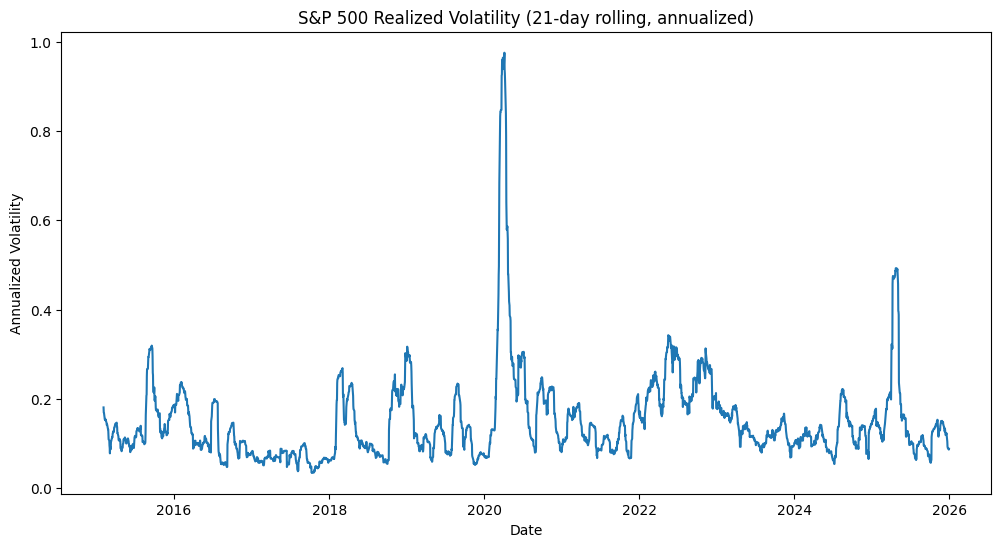

In [2]:
data['realized_volatility'] = data['log_return'].rolling(window=21).std() * np.sqrt(252)
data = data.dropna()

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['realized_volatility'])
plt.title('S&P 500 Realized Volatility (21-day rolling, annualized)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.show()

In [3]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

In [4]:
S_current = data['Close'].iloc[-1]
K = S_current # at-the-money option
T = 30 / 365 # 30 days to expiration
r = 0.05 # risk-free interest rate

# Scenario 1: constant historical volatility
sigma_historical = data['log_return'].std() * np.sqrt(252)
# Scenario 2: realized volatility (last 21 days)
sigma_recent = data['realized_volatility'].iloc[-1]

price_historical = black_scholes_call(S_current, K, T, r, sigma_historical)
price_recent = black_scholes_call(S_current, K, T, r, sigma_recent)

print(f"Historical volatility: {sigma_historical:.4f}, Call Price: {price_historical:.2f}")
print(f"Recent realized volatility: {sigma_recent:.4f}, Call Price: {price_recent:.2f}")
print(f"Difference: {abs(price_historical - price_recent):.2f} ({abs(price_historical - price_recent)/price_historical*100:.1f}%)")

Historical volatility: 0.1796, Call Price: 154.80
Recent realized volatility: 0.0884, Call Price: 84.04
Difference: 70.76 (45.7%)


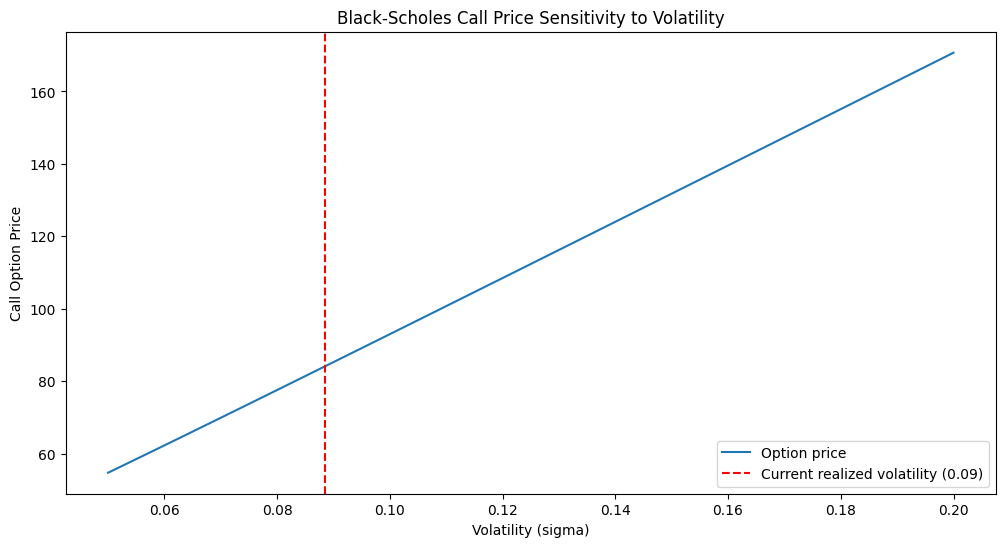

In [5]:
sigmas = np.linspace(0.05, 0.2, 50)
prices = [black_scholes_call(S_current, K, T, r, s) for s in sigmas]
plt.figure(figsize=(12, 6))
plt.plot(sigmas, prices, label='Option price')
plt.axvline(sigma_recent, color='r', linestyle='--', label=f"Current realized volatility ({sigma_recent:.2f})")
plt.xlabel('Volatility (sigma)')
plt.ylabel('Call Option Price')
plt.title('Black-Scholes Call Price Sensitivity to Volatility')
plt.legend()
plt.savefig('../docs/black_scholes_sensitivity.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary 

Implemented the Black-Scholes option pricing formula from scratch and compared option prices
under two volatility assumptions:

- **Historical volatility** (full sample, 2015–2026): σ = 0.1796
- **Recent realized volatility** (last 21 trading days): σ = 0.0884

For a 30-day at-the-money call option (S = K ≈ current S&P 500 price, r = 5%):

| Volatility assumption | σ | Call price |
|---|---|---|
| Historical (full sample) | 0.1796 | $154.80 |
| Recent (21-day realized) | 0.0884 | $84.04 |

The difference in price (45.7%) demonstrates that Black-Scholes valuations are highly sensitive
to the volatility input — and since volatility is not constant (confirmed by the Ljung-Box test
in 01_data_and_stationarity), using a single historical volatility estimate can meaningfully mis-price options
depending on current market conditions. This motivates the volatility forecasting model built
in next part of this project.